# 00 — Download e Exploração do Dataset FordA

**Objetivo:** Baixar o dataset FordA (UCR Archive), explorar suas características, visualizar sinais, demonstrar decomposição wavelet e extrair features para os próximos experimentos.

**FordA:** Classificação binária de sinais de sensores industriais (Ford motor). 3601 amostras de treino e 1320 de teste, cada uma com 500 pontos temporais.

In [10]:
import os, sys, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Paths do projeto
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../../'))

from config.experiment_config import (
    DATA_DIR, RESULTS_DIR, WAVELET_CONFIG, FORDA_CONFIG, SEED
)
from src.data_loader import FordADataLoader
from src.feature_extraction import WaveletFeatureExtractor
from src.visualization import ExperimentVisualizer

np.random.seed(SEED)
print(f"Data dir: {DATA_DIR}")
print(f"FordA config: {FORDA_CONFIG}")

Data dir: /home/felipeteodoro/projetos/LearnableWaveletLayer/tests/ford-a/data
FordA config: {'dataset_name': 'FordA', 'n_classes': 2, 'sequence_length': 500, 'n_features': 1, 'class_labels': {0: 'Normal', 1: 'Anomaly'}, 'original_labels': {-1: 0, 1: 1}, 'val_fraction': 0.15, 'random_seed': 42}


## 1. Download e Preparação dos Dados

In [2]:
loader = FordADataLoader(data_dir=DATA_DIR, random_seed=SEED)
data = loader.prepare(val_fraction=FORDA_CONFIG["val_fraction"])

X_train, y_train = data["X_train"], data["y_train"]
X_val, y_val = data["X_val"], data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]

print(f"\nShapes:")
print(f"  X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}   y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}  y_test:  {y_test.shape}")

✓ FordA baixado via aeon (3601 train, 1320 test)

✓ Dados salvos em /home/felipeteodoro/projetos/LearnableWaveletLayer/tests/ford-a/data
  Train: (3060, 500)  |  Val: (541, 500)  |  Test: (1320, 500)
  Classes train: {'0': 1569, '1': 1491}

Shapes:
  X_train: (3060, 500)  y_train: (3060,)
  X_val:   (541, 500)   y_val:   (541,)
  X_test:  (1320, 500)  y_test:  (1320,)


## 2. Exploração do Dataset

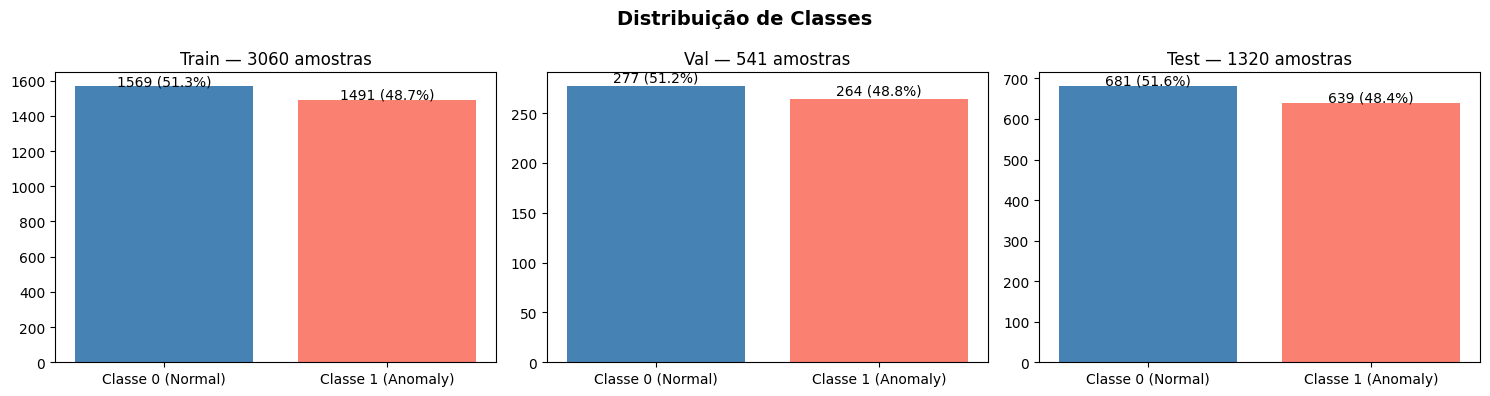


Estatísticas dos sinais (X_train):
  Média global:    -0.000000
  Desvio padrão:   0.998999
  Min:             -4.617693
  Max:             5.059228
  Comprimento:     500


In [3]:
# Distribuição de classes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y) in zip(axes, [("Train", y_train), ("Val", y_val), ("Test", y_test)]):
    unique, counts = np.unique(y, return_counts=True)
    ax.bar(unique, counts, color=['steelblue', 'salmon'])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Classe 0 (Normal)", "Classe 1 (Anomaly)"])
    ax.set_title(f"{name} — {len(y)} amostras")
    for u, c in zip(unique, counts):
        ax.text(u, c + 5, f"{c} ({100*c/len(y):.1f}%)", ha='center', fontsize=10)
plt.suptitle("Distribuição de Classes", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Estatísticas básicas do sinal
print("\nEstatísticas dos sinais (X_train):")
print(f"  Média global:    {X_train.mean():.6f}")
print(f"  Desvio padrão:   {X_train.std():.6f}")
print(f"  Min:             {X_train.min():.6f}")
print(f"  Max:             {X_train.max():.6f}")
print(f"  Comprimento:     {X_train.shape[1]}")

## 3. Visualização dos Sinais

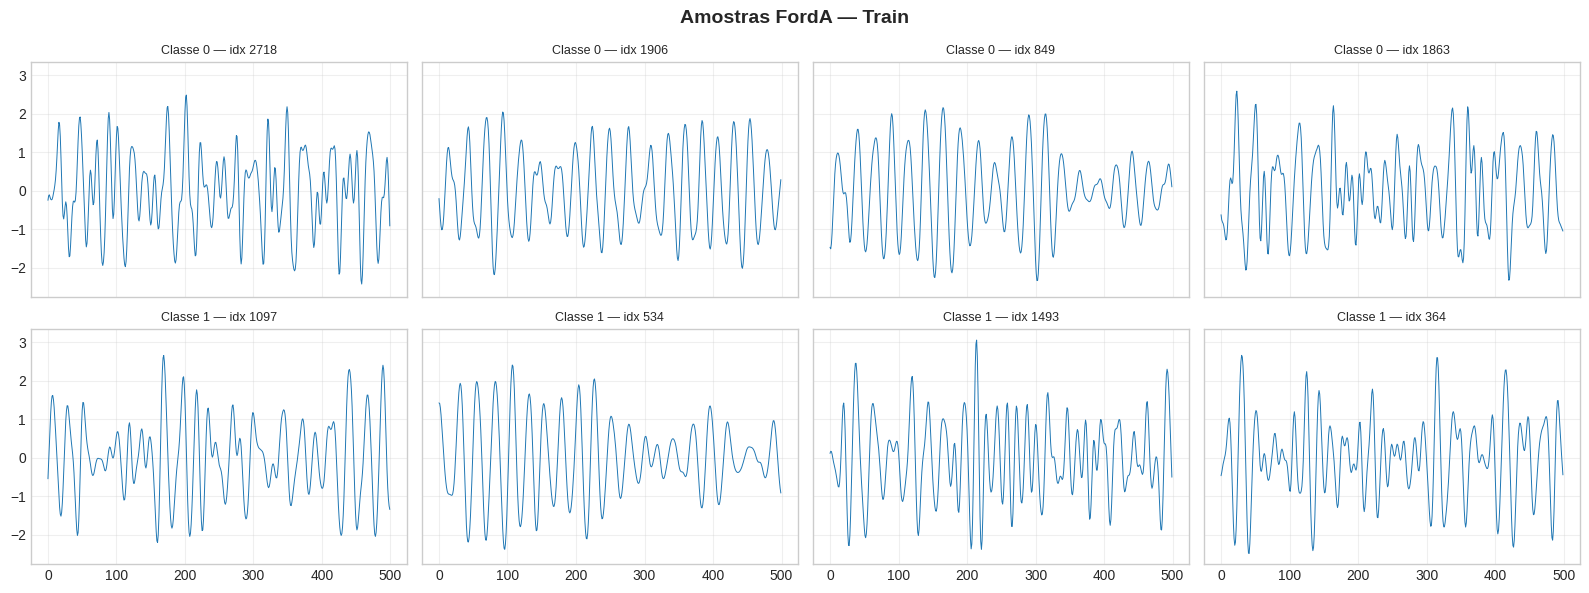

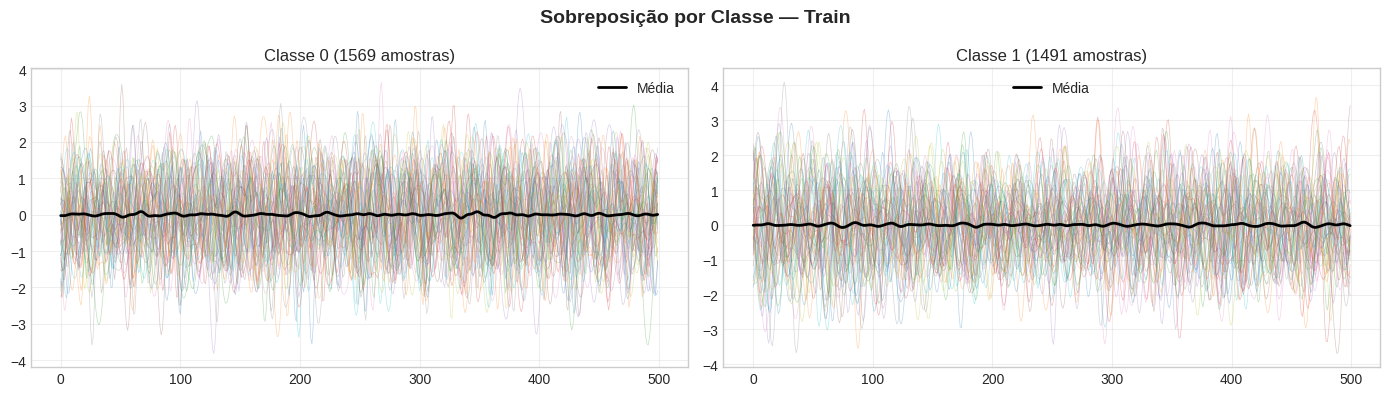

In [4]:
viz = ExperimentVisualizer()

# Amostras individuais por classe
viz.plot_samples(X_train, y_train, n_per_class=4,
                 title="Amostras FordA — Train",
                 save_path=RESULTS_DIR / "samples_per_class.png")
plt.show()

# Sobreposição por classe
viz.plot_class_overlay(X_train, y_train, n_per_class=50,
                       title="Sobreposição por Classe — Train",
                       save_path=RESULTS_DIR / "class_overlay.png")
plt.show()

## 4. Análise Espectral

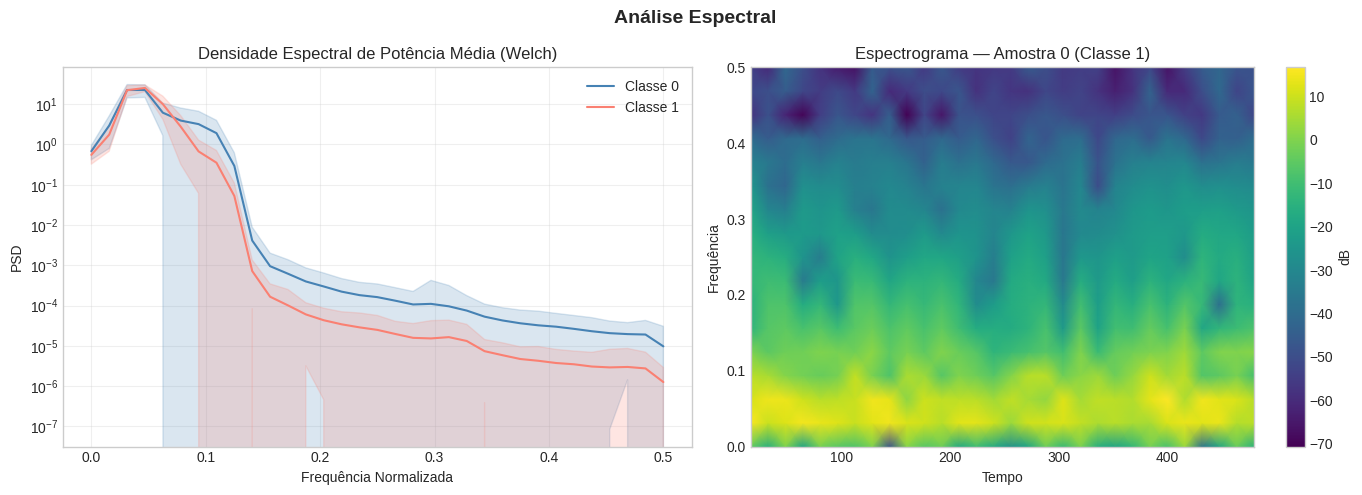

In [5]:
from scipy.signal import welch

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls, (color, label) in enumerate([('steelblue', 'Classe 0'), ('salmon', 'Classe 1')]):
    idxs = np.where(y_train == cls)[0]
    # Média do PSD por classe
    psd_list = []
    for idx in idxs[:200]:  # amostrar 200 para eficiência
        freqs, psd = welch(X_train[idx], fs=1.0, nperseg=64)
        psd_list.append(psd)
    psd_mean = np.mean(psd_list, axis=0)
    psd_std = np.std(psd_list, axis=0)

    axes[0].semilogy(freqs, psd_mean, color=color, label=label, linewidth=1.5)
    axes[0].fill_between(freqs, psd_mean - psd_std, psd_mean + psd_std, color=color, alpha=0.2)

axes[0].set_xlabel("Frequência Normalizada")
axes[0].set_ylabel("PSD")
axes[0].set_title("Densidade Espectral de Potência Média (Welch)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Espectrograma de uma amostra
from scipy.signal import spectrogram
sample_idx = 0
f, t, Sxx = spectrogram(X_train[sample_idx], fs=1.0, nperseg=32, noverlap=16)
axes[1].pcolormesh(t, f, 10 * np.log10(Sxx + 1e-12), shading='gouraud', cmap='viridis')
axes[1].set_xlabel("Tempo")
axes[1].set_ylabel("Frequência")
axes[1].set_title(f"Espectrograma — Amostra {sample_idx} (Classe {int(y_train[sample_idx])})")
plt.colorbar(axes[1].collections[0], ax=axes[1], label="dB")

plt.suptitle("Análise Espectral", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / "spectral_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Decomposição Wavelet

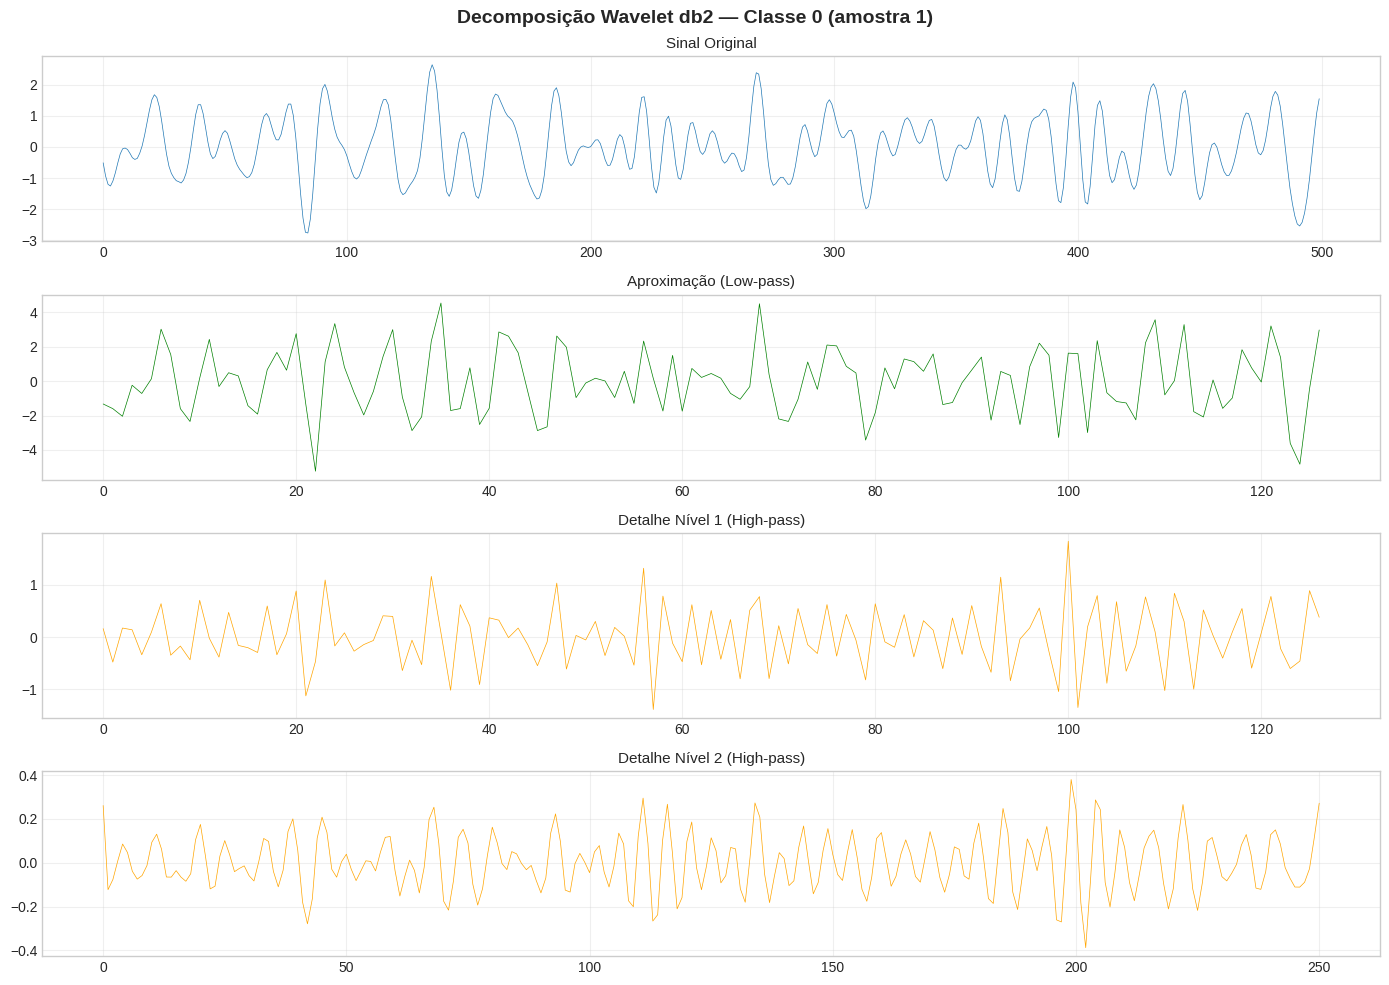

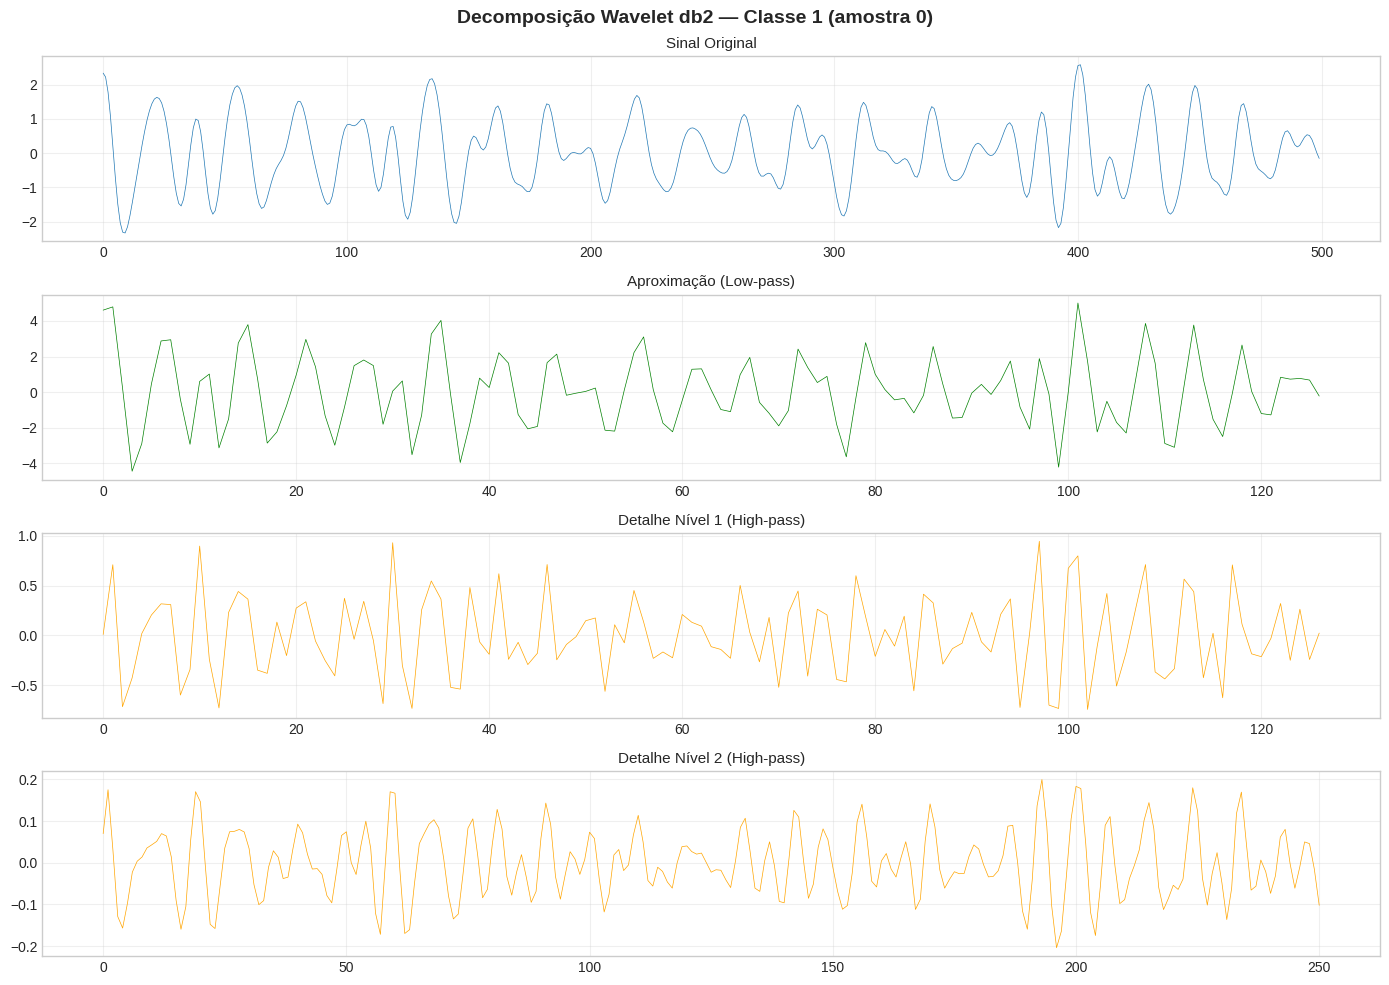

In [6]:
import pywt

wfe = WaveletFeatureExtractor(
    wavelet=WAVELET_CONFIG["wavelet_type"],
    level=WAVELET_CONFIG["decomposition_level"],
    mode=WAVELET_CONFIG["mode"],
)

# Decomposição de uma amostra de cada classe
for cls in [0, 1]:
    idx = np.where(y_train == cls)[0][0]
    signal = X_train[idx]
    approx, details = wfe.decompose(signal)
    viz.plot_wavelet_decomposition(
        signal, approx, details,
        title=f"Decomposição Wavelet db2 — Classe {cls} (amostra {idx})",
        save_path=RESULTS_DIR / f"wavelet_decomposition_class{cls}.png",
    )
    plt.show()

## 6. Extração de Features

In [ ]:
from sklearn.feature_selection import mutual_info_classif

# === 1) Features estatísticas dos coeficientes wavelet ===
print("Extraindo features estatísticas wavelet...")
X_train_stats = wfe.extract_features(X_train)
X_val_stats = wfe.extract_features(X_val)
X_test_stats = wfe.extract_features(X_test)
stat_names = wfe.get_feature_names()
print(f"  Stats shape: treino={X_train_stats.shape}")

# === 2) Coeficientes wavelet brutos (concatenados) ===
print("Extraindo coeficientes wavelet brutos...")
X_train_coeffs = wfe.get_coefficients(X_train)
X_val_coeffs = wfe.get_coefficients(X_val)
X_test_coeffs = wfe.get_coefficients(X_test)
coeff_names = [f"wcoeff_{i}" for i in range(X_train_coeffs.shape[1])]
print(f"  Coefficients shape: treino={X_train_coeffs.shape}")

# === 3) Concatenar: stats + coeficientes brutos (como no experimento sintético) ===
X_train_feat = np.hstack([X_train_stats, X_train_coeffs])
X_val_feat = np.hstack([X_val_stats, X_val_coeffs])
X_test_feat = np.hstack([X_test_stats, X_test_coeffs])
feature_names = stat_names + coeff_names
print(f"\nFeatures combinadas (stats + coeffs):")
print(f"  Treino: {X_train_feat.shape}  ({len(stat_names)} stats + {len(coeff_names)} coeffs)")
print(f"  Val:    {X_val_feat.shape}")
print(f"  Teste:  {X_test_feat.shape}")

# Mutual Information com a variável alvo (sobre features estatísticas apenas, mais rápido)
mi_scores_stats = mutual_info_classif(X_train_stats, y_train, random_state=42)
mi_df = pd.DataFrame({"feature": stat_names, "mi_score": mi_scores_stats})
mi_df = mi_df.sort_values("mi_score", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
top_n = min(20, len(mi_df))
ax.barh(range(top_n), mi_df["mi_score"].values[:top_n])
ax.set_yticks(range(top_n))
ax.set_yticklabels(mi_df["feature"].values[:top_n])
ax.invert_yaxis()
ax.set_xlabel("Mutual Information Score")
ax.set_title("Top Features Estatísticas — Mutual Information com a Classe")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "feature_mutual_information.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTop 10 features estatísticas:")
print(mi_df.head(10).to_string(index=False))

Extraindo features estatísticas wavelet...


## 7. Salvar Dados Processados

In [ ]:
# Salvar arrays processados
np.save(DATA_DIR / "X_train.npy", X_train)
np.save(DATA_DIR / "X_val.npy", X_val)
np.save(DATA_DIR / "X_test.npy", X_test)
np.save(DATA_DIR / "y_train.npy", y_train)
np.save(DATA_DIR / "y_val.npy", y_val)
np.save(DATA_DIR / "y_test.npy", y_test)

# Salvar features combinadas (stats + coeficientes brutos)
np.save(DATA_DIR / "X_train_wavelet_features.npy", X_train_feat)
np.save(DATA_DIR / "X_val_wavelet_features.npy", X_val_feat)
np.save(DATA_DIR / "X_test_wavelet_features.npy", X_test_feat)

# Salvar metadados
import json

metadata = {
    "dataset": "FordA",
    "source": "UCR Time Series Classification Archive",
    "task": "binary_classification",
    "signal_length": int(X_train.shape[1]),
    "n_classes": 2,
    "class_mapping": {"-1": 0, "1": 1},
    "train_samples": int(X_train.shape[0]),
    "val_samples": int(X_val.shape[0]),
    "test_samples": int(X_test.shape[0]),
    "wavelet": WAVELET_CONFIG["wavelet_type"],
    "decomposition_level": WAVELET_CONFIG["decomposition_level"],
    "n_wavelet_features": int(X_train_feat.shape[1]),
    "n_stat_features": len(stat_names),
    "n_coeff_features": len(coeff_names),
    "feature_names": feature_names,
    "feature_composition": "statistical_features + raw_wavelet_coefficients",
}

with open(DATA_DIR / "ford_a_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Dados salvos com sucesso!")
print(f"\nResumo:")
print(f"  Sinais: X_train {X_train.shape}, X_val {X_val.shape}, X_test {X_test.shape}")
print(f"  Labels: y_train {y_train.shape}, y_val {y_val.shape}, y_test {y_test.shape}")
print(f"  Features wavelet: {X_train_feat.shape[1]} ({len(stat_names)} stats + {len(coeff_names)} coeffs)")
print(f"  Metadados: {DATA_DIR / 'ford_a_metadata.json'}")

Dados salvos com sucesso!

Resumo:
  Sinais: X_train (3060, 500), X_val (541, 500), X_test (1320, 500)
  Labels: y_train (3060,), y_val (541,), y_test (1320,)
  Features wavelet: 51 features por amostra
  Metadados: /home/felipeteodoro/projetos/LearnableWaveletLayer/tests/ford-a/data/ford_a_metadata.json
